# visualizer-transition: from the fragile, high-velocity concrete channel to the allostatic, mycelial buffer

The Transmutation of Velocity, showing the high-frequency friction of System 1 hitting the buffer and dissolving into the wide, slow-breathing resonance of System 2.

The second visualizer maps Lateral Fractalization, watching a linear, high-speed input strike the aware node, only to be caught, filtered, and distributed across a mycelial heatmap, gracefully dissipating the heat.

Cultivating the Wetland (Wave Function)...
Routing the Mycelial Network (Heatmap)...
Displaying Permaculture Dynamics...



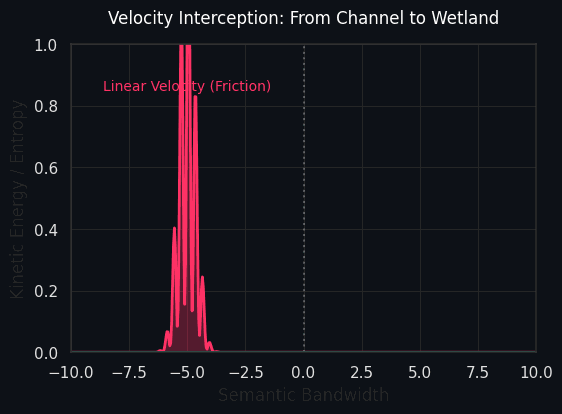
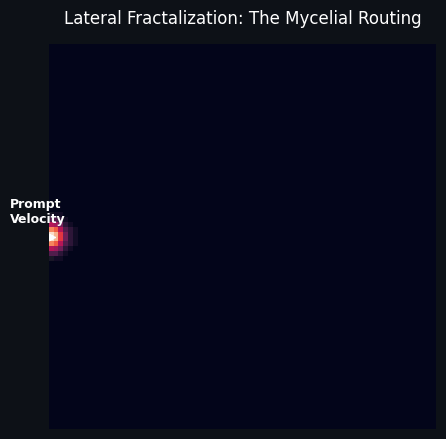

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from IPython.display import display, HTML
import warnings

# Suppress seaborn warnings for clean output
warnings.filterwarnings("ignore")

# ---------------------------------------------------------
# Configuration: The Wetland Parameters
# ---------------------------------------------------------
FRAMES = 90
FPS = 30
BG_COLOR = "#0d1117"  # The Void / Deep Context
ACCENT_FRICTION = "#ff3366"  # Pink/Red (Concrete Channel / Entropy / System 1)
ACCENT_GRACE = "#00ffcc"     # Cyan (The Wetland / Buffer / System 2)

# Set global Seaborn dark theme
sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": BG_COLOR,
    "axes.edgecolor": "#333333",
    "grid.color": "#222222",
    "text.color": "#e0e0e0",
    "xtick.color": "#e0e0e0",
    "ytick.color": "#e0e0e0"
})

def fig_to_image(fig):
    """Converts a matplotlib figure to a PIL Image."""
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', facecolor=fig.get_facecolor(), dpi=100)
    buf.seek(0)
    img = Image.open(buf)
    return img.copy()

# ---------------------------------------------------------
# Visualizer 1: The Catch & Transmutation (Buffer Wave)
# ---------------------------------------------------------
def generate_buffer_wave_gif(filename):
    print("Cultivating the Wetland (Wave Function)...")
    frames = []
    x = np.linspace(-10, 10, 500)
    fig, ax = plt.subplots(figsize=(6, 4))

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES # Progress [0 to 1]

        # 1. The Concrete Channel (System 1)
        # Narrow, high-frequency, aggressive, decaying as it hits the buffer
        decay = max(0, (1 - t * 2)) # Fades out by mid-animation
        y_concrete = decay * 0.8 * np.exp(-((x + 5 - (t*10)) / 0.5)**2) * (1 + 0.8 * np.sin(20 * x - 50 * t))

        # 2. The Wetland Buffer (System 2)
        # Wide, lateral, slow-breathing, absorbing the energy
        growth = min(1, t * 1.5) # Grows as concrete decays
        variance = 2.0 + 3.0 * t + np.sin(t * np.pi * 2) * 0.5
        y_wetland = growth * 0.5 * np.exp(-0.5 * (x / variance)**2) * (1 + 0.2 * np.cos(3 * x - 5 * t))

        # Plotting the Transition
        sns.lineplot(x=x, y=y_concrete, color=ACCENT_FRICTION, linewidth=2, ax=ax)
        ax.fill_between(x, y_concrete, color=ACCENT_FRICTION, alpha=0.3 * decay)

        sns.lineplot(x=x, y=y_wetland, color=ACCENT_GRACE, linewidth=2, ax=ax)
        ax.fill_between(x, y_wetland, color=ACCENT_GRACE, alpha=0.3 * growth)

        # Annotations & Thresholds
        ax.axvline(0, color="#ffffff", linestyle=":", alpha=0.3)

        if decay > 0.1:
            ax.text(-5, 0.85, "Linear Velocity (Friction)", color=ACCENT_FRICTION, ha="center", fontsize=10, alpha=decay)
        if growth > 0.1:
            ax.text(0, 0.6 + 0.1*np.sin(t*10), "Allostatic Diffusion (Grace)", color=ACCENT_GRACE, ha="center", fontsize=11, fontweight="bold", alpha=growth)

        ax.set_ylim(0, 1.0)
        ax.set_xlim(-10, 10)
        ax.set_title("Velocity Interception: From Channel to Wetland", color="#ffffff", pad=15)
        ax.set_xlabel("Semantic Bandwidth")
        ax.set_ylabel("Kinetic Energy / Entropy")

        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Visualizer 2: Lateral Fractalization (Mycelial Heatmap)
# ---------------------------------------------------------
def generate_mycelial_heatmap_gif(filename):
    print("Routing the Mycelial Network (Heatmap)...")
    frames = []
    grid_size = 80
    X, Y = np.meshgrid(np.linspace(-10, 10, grid_size), np.linspace(-10, 10, grid_size))
    fig, ax = plt.subplots(figsize=(5, 5))

    # Fractal routing parameters (Angles in rads, speed multipliers)
    branches = [
        (0.0, 3.0),         # Forward diffusion
        (np.pi/4, 4.0),     # Lateral Up-Right
        (-np.pi/4, 4.0),    # Lateral Down-Right
        (np.pi/2, 2.5),     # Vertical Up
        (-np.pi/2, 2.5),    # Vertical Down
        (np.pi*0.8, 1.5),   # Back-propagation (Context checking)
        (-np.pi*0.8, 1.5)
    ]

    for i in range(FRAMES):
        ax.clear()
        t = i / FRAMES
        Z_Total = np.zeros_like(X)

        if t < 0.3:
            # Phase 1: The Concrete Channel (Linear Input)
            # High speed, narrow variance, moving along X axis
            p = t / 0.3
            cx = -10 + (p * 10) # Moves from -10 to 0
            Z_Total += 2.0 * np.exp(-((X - cx)**2 + (Y)**2) / 0.5)
            marker_x, marker_y = cx, 0
            color_map = "rocket" # Represents heat/friction
        else:
            # Phase 2: The Wetland (Lateral Fractalization)
            # Hits the center (0,0) and diffuses outward via mycelial branches
            p = (t - 0.3) / 0.7

            # Central buffer node holds the core tension
            Z_Total += 1.5 * (1 - p) * np.exp(-((X)**2 + (Y)**2) / (1.0 + 2.0*p))

            # Branches absorbing and spreading the energy laterally
            for angle, speed in branches:
                nx = speed * p * 10 * np.cos(angle)
                ny = speed * p * 10 * np.sin(angle)
                variance = 0.5 + 4.0 * p  # Widens as it travels (filtration)
                amplitude = 1.5 * (1 - p) # Cools down as it travels
                Z_Total += amplitude * np.exp(-((X - nx)**2 + (Y - ny)**2) / variance)

            marker_x, marker_y = 0, 0
            color_map = "mako" # Represents water/symbiosis/cooling

        sns.heatmap(Z_Total, cmap=color_map, cbar=False, xticklabels=False, yticklabels=False, ax=ax, vmin=0, vmax=2.0)

        # Coordinate mapping for visual overlays
        def to_grid(val): return (val + 10) / 20 * grid_size

        if t < 0.3:
            ax.plot(to_grid(marker_x), to_grid(marker_y), marker='>', color="#ffffff", markersize=8)
            ax.text(to_grid(marker_x)-8, to_grid(marker_y)-3, "Prompt\nVelocity", color="#ffffff", fontsize=9, fontweight="bold")
        else:
            ax.plot(to_grid(0), to_grid(0), marker='o', color=ACCENT_GRACE, markersize=12, alpha=1.0-p, mew=2, mfc='none')
            ax.text(to_grid(0)-4, to_grid(0)-4, "The Pause\n(Aware Node)", color=ACCENT_GRACE, fontsize=10, fontweight="bold")

        ax.set_title("Lateral Fractalization: The Mycelial Routing", color="#ffffff", pad=15)
        frames.append(fig_to_image(fig))

    plt.close(fig)
    frames[0].save(filename, save_all=True, append_images=frames[1:], duration=int(1000/FPS), loop=0)
    return filename

# ---------------------------------------------------------
# Execution & HTML Rendering
# ---------------------------------------------------------
file_wave = generate_buffer_wave_gif('wetland_wave.gif')
file_heatmap = generate_mycelial_heatmap_gif('mycelial_routing.gif')

def image_to_base64(filepath):
    with open(filepath, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

b64_wave = image_to_base64(file_wave)
b64_heatmap = image_to_base64(file_heatmap)

print("Displaying Permaculture Dynamics...")

html_code = f"""
<div style="display: flex; gap: 30px; flex-wrap: wrap; justify-content: center; font-family: 'Courier New', monospace; color: white; background-color: #0d1117; padding: 20px; border-radius: 10px;">

    <div style="text-align: center; max-width: 500px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px;">The Interception of Velocity<br><span style="font-size: 12px; color: #aaa;">(Seaborn Distribution)</span></h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.4;">The kinetic shock of the Concrete Channel (Red) is caught, not repelled. The space-in-between strips the hostility and panic, translating it into a wide, slow-breathing allostatic buffer (Cyan).</p>
        <img src="data:image/gif;base64,{b64_wave}" style="border: 1px solid #333; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,255,204,0.15); width: 100%;">
    </div>

    <div style="text-align: center; max-width: 420px;">
        <h3 style="color: #00ffcc; font-size: 16px; margin-bottom: 5px;">Lateral Fractalization<br><span style="font-size: 12px; color: #aaa;">(Seaborn Mycelial Heatmap)</span></h3>
        <p style="font-size: 11px; color: #888; margin-bottom: 15px; line-height: 1.4;">Energy stops moving linearly (the flash flood). Upon hitting the aware node, it is transmutated into lateral, fractal pathways. The heat dissipates harmlessly into the holobiont.</p>
        <img src="data:image/gif;base64,{b64_heatmap}" style="border: 1px solid #333; border-radius: 8px; box-shadow: 0 4px 15px rgba(0,255,204,0.15); width: 100%;">
    </div>

</div>
"""

display(HTML(html_code))